# Phase 3: Data Preparation

This phase covers feature engineering, data transformation, and preparing the dataset for modelling.


# Notebook 5 - Feature Engineering & Model Training
## Cookie Cats A/B Testing

**Phase:** CRISP-DM Phase 3 & 4 - Data Preparation & Modelling


---

## Step 0 - Environment Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})
os.makedirs('../reports/figures', exist_ok=True)
print("Environment ready.")

Environment ready.


---
## Step 1 - Load Augmented Dataset

In [2]:
df = pd.read_csv('../data/processed/cookie_cats_augmented.csv')
print(f"Augmented dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")

Augmented dataset: 90,189 rows x 11 cols


---
## Step 2 - Feature Engineering

In [3]:
from src.processing import engineer_features

df_feat = engineer_features(df)
print(f"Features added. Shape: {df_feat.shape}")
df_feat.head()


Engineered features added. New shape: (90189, 15)
Features added. Shape: (90189, 15)


,userid,version,sum_gamerounds,retention_1,retention_7,industry_d1_retention,industry_d7_retention,industry_d30_retention,industry_avg_session_min,genre_market_share_pct,retention_vs_industry,gamerounds_bin,high_engagement,retention_1_x_rounds,rounds_per_day_proxy
0,116,gate_30,3,0,0,0.45,0.22,0.09,5.8,15.0,-0.22,casual,0,0,0.428571
1,337,gate_30,38,1,0,0.45,0.22,0.09,5.8,15.0,-0.22,moderate,0,38,5.428571
2,377,gate_40,165,1,0,0.45,0.22,0.09,5.8,15.0,-0.22,active,1,165,23.571429
3,483,gate_40,1,0,0,0.45,0.22,0.09,5.8,15.0,-0.22,inactive,0,0,0.142857
4,488,gate_40,179,1,1,0.45,0.22,0.09,5.8,15.0,0.78,active,1,179,25.571429


---
## Step 3 - Quick EDA on Engineered Features

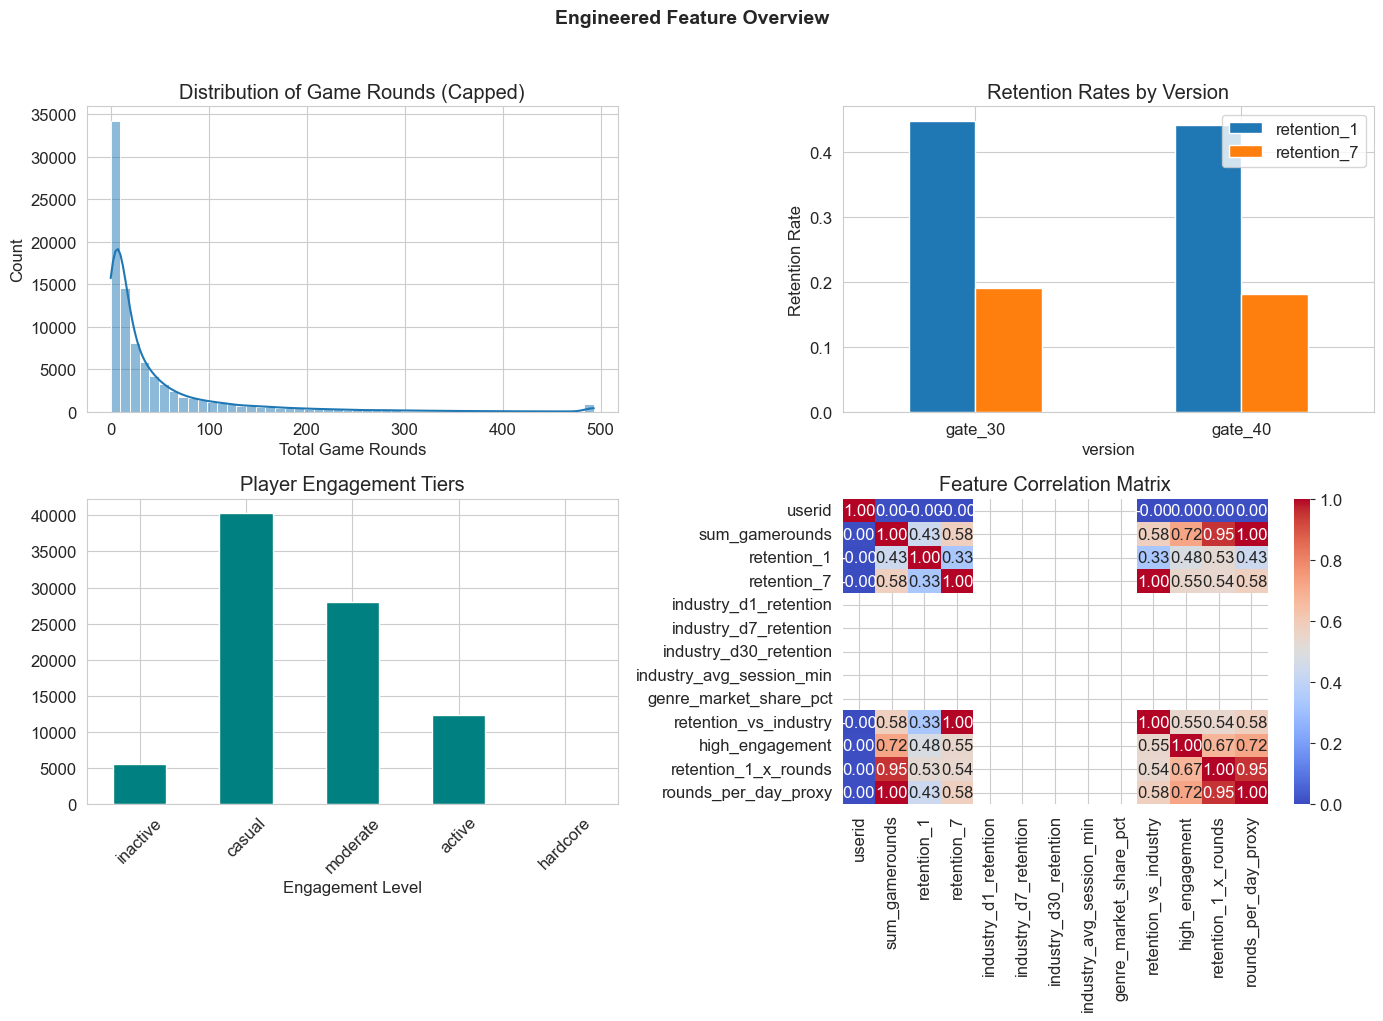

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Game rounds distribution
sns.histplot(df_feat['sum_gamerounds'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Game Rounds (Capped)')
axes[0, 0].set_xlabel('Total Game Rounds')

# Retention by version
retention_by_version = df_feat.groupby('version')[['retention_1', 'retention_7']].mean()
retention_by_version.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Retention Rates by Version')
axes[0, 1].set_ylabel('Retention Rate')
axes[0, 1].tick_params(axis='x', rotation=0)

# Engagement tier distribution
df_feat['gamerounds_bin'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Player Engagement Tiers')
axes[1, 0].set_xlabel('Engagement Level')
axes[1, 0].tick_params(axis='x', rotation=45)

# Correlation heatmap
numeric_cols = df_feat.select_dtypes(include='number').columns
corr = df_feat[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Matrix')

plt.suptitle('Engineered Feature Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/feature_eda.png', dpi=150, bbox_inches='tight')
plt.show()
